## **Segundo Proyecto: Algoritmos de Búsqueda** 
**Curso:** Inteligencia Artificial - CC3085  



**Descripción General:**
En este proyecto se implementan y comparan diferentes algoritmos de búsqueda para resolver laberintos generados de forma aleatoria. Se estudian tanto algoritmos de generación de laberintos como técnicas de búsqueda clásicas en inteligencia artificial.

El objetivo principal es analizar el desempeño de algoritmos como BFS, DFS, Dijkstra y A*, evaluando métricas como:

- Nodos explorados
- Longitud del camino encontrado
- Tiempo de ejecución

Además, se generan múltiples escenarios experimentales para obtener conclusiones fundamentadas sobre cuál algoritmo es más eficiente en distintos contextos.

---

### ***Configuración Base***

Se importan las librerías necesarias y se define el grid $M \times N$, estructuras auxiliares para representar el laberinto y sus vecinos, y las constantes globales del proyecto.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import random
import time
import heapq
import pandas as pd
from collections import deque
from IPython.display import clear_output

#### ***Constantes Globales***

Para evitar inconsistencias entre implementaciones, todos los parámetros del proyecto se centralizan aquí.

**Parámetros**

- Tamaños de grid (según el PDF):
  - Demo Problema 1: $31 \times 41$
  - Problema 2 (prueba): $60 \times 80$ → se usa $61 \times 81$ para garantizar dimensiones impares
  - Problema 3 (benchmark): $45 \times 55$

- Número de simulaciones: $K = 25$

- Punto inicial: $(1,1)$  
- Punto final: $(\text{filas}-2, \text{columnas}-2)$

- Heurística A*: Distancia Manhattan

In [2]:
# Tamaños de grid por problema 
FILAS_P1, COLS_P1 = 31, 41   # Demo generación
FILAS_P2, COLS_P2 = 61, 81   # Problema 2: 60x80 → impar
FILAS_P3, COLS_P3 = 45, 55   # Benchmark

K_SIMULACIONES = 25

# Colores para visualizaciones 
COLOR_PARED    = 0
COLOR_CAMINO   = 1
COLOR_VISITADO = 2
COLOR_RUTA     = 3
COLOR_INICIO   = 4
COLOR_FIN      = 5

CMAP_LABERINTO = mcolors.ListedColormap(['black', 'white', '#90CAF9', '#FFD600', '#00E676', '#FF1744'])
# 0=pared  1=camino  2=explorado  3=ruta  4=inicio  5=fin

def dibujar_laberinto(laberinto, titulo="Generando Laberinto...", pausa=0.05):
    clear_output(wait=True)
    plt.figure(figsize=(10, 6))
    plt.imshow(laberinto, cmap='binary')
    plt.title(titulo, fontsize=13)
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.show()
    time.sleep(pausa)

### ***Generación de Laberintos***

Se implementan dos algoritmos con estructuras contrastantes para analizar su impacto en los algoritmos de búsqueda.

***Algoritmo de Prim***

Genera un laberinto haciendo crecer un Árbol de Expansión Mínima (MST) desde un punto inicial aleatorio. En cada paso, elige aleatoriamente una pared que separa una celda visitada de una no visitada y la elimina.

**Características:**
- Estructura orgánica, con crecimiento radial
- Muchos callejones sin salida y alta ramificación
- El camino solución suele ser tortuoso

**Impacto en búsqueda:**
Fuerza a BFS y DFS a explorar una gran cantidad de nodos antes de encontrar la salida.

In [3]:
def generar_prim(filas=FILAS_P1, columnas=COLS_P1, animar=False):
    r = filas    if filas    % 2 != 0 else filas    + 1
    c = columnas if columnas % 2 != 0 else columnas + 1

    laberinto = np.zeros((r, c), dtype=int)  # 0 = pared

    # Celda inicial aleatoria en posición impar
    start_r = random.randrange(1, r, 2)
    start_c = random.randrange(1, c, 2)
    laberinto[start_r, start_c] = 1

    # Lista de paredes candidatas
    paredes = []
    for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
        nr, nc = start_r + dr, start_c + dc
        if 0 < nr < r-1 and 0 < nc < c-1:
            paredes.append((nr, nc, start_r, start_c))

    while paredes:
        idx = random.randint(0, len(paredes) - 1)
        pr, pc, vr, vc = paredes.pop(idx)

        dr, dc = pr - vr, pc - vc
        nr, nc = pr + dr, pc + dc

        if 0 < nr < r-1 and 0 < nc < c-1 and laberinto[nr, nc] == 0:
            laberinto[pr, pc] = 1  # romper pared
            laberinto[nr, nc] = 1  # marcar nueva celda

            for ddr, ddc in [(-1,0),(1,0),(0,-1),(0,1)]:
                nnr, nnc = nr + ddr, nc + ddc
                if 0 < nnr < r-1 and 0 < nnc < c-1 and laberinto[nnr, nnc] == 0:
                    paredes.append((nnr, nnc, nr, nc))

            if animar:
                dibujar_laberinto(laberinto, "Prim en construcción...", 0.01)

    # Garantizar entrada y salida
    laberinto[1, 1]      = 1
    laberinto[r-2, c-2]  = 1

    if animar:
        dibujar_laberinto(laberinto, "Laberinto Prim — Terminado", 0)

    return laberinto
    

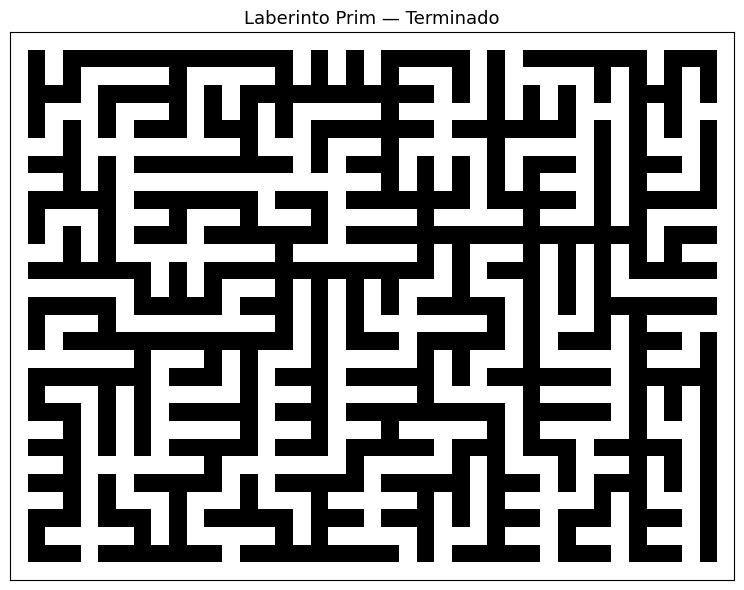

In [4]:
lab_prim = generar_prim(FILAS_P1, COLS_P1, animar=True)

***División Recursiva***

Parte de un espacio completamente abierto y lo subdivide recursivamente añadiendo muros con un hueco (puerta) en cada división. El enfoque es divide y vencerás.

**Características:**
- Pasillos largos y rectos, estructura tipo "bloques"
- Pocas ramificaciones, camino más directo
- Visualmente más simétrico

**Impacto en búsqueda:**
Los corredores largos y únicos de este tipo de laberinto favorecen a **DFS**: al explorar en profundidad, DFS puede recorrer un corredor directamente hacia la meta sin necesidad de retroceder. En cambio, A* pierde parte de su ventaja porque los pasillos no siguen la dirección Manhattan — las paredes divisorias fuerzan rodeos que la heurística no anticipa.

In [5]:
def generar_division_recursiva(filas=FILAS_P1, columnas=COLS_P1, animar=False):

    r = filas    if filas    % 2 != 0 else filas    + 1
    c = columnas if columnas % 2 != 0 else columnas + 1

    # Iniciar con espacio abierto y borde de paredes
    laberinto = np.ones((r, c), dtype=int)
    laberinto[0, :]  = 0
    laberinto[-1, :] = 0
    laberinto[:, 0]  = 0
    laberinto[:, -1] = 0

    def dividir(rmin, rmax, cmin, cmax):
        if rmax - rmin < 2 or cmax - cmin < 2:
            return

        if (rmax - rmin) == (cmax - cmin):
            horizontal = random.choice([True, False])
        else:
            horizontal = (rmax - rmin) > (cmax - cmin)

        if horizontal:
            filas_par = list(range(rmin + 1, rmax, 2))
            if not filas_par: return
            muro_r = random.choice(filas_par)

            cols_impar = list(range(cmin, cmax + 1, 2))
            if not cols_impar: return
            paso_c = random.choice(cols_impar)

            laberinto[muro_r, cmin:cmax+1] = 0
            laberinto[muro_r, paso_c]      = 1

            if animar: dibujar_laberinto(laberinto, "División Recursiva...", 0.05)

            dividir(rmin,       muro_r - 1, cmin, cmax)
            dividir(muro_r + 1, rmax,       cmin, cmax)
        else:
            cols_par = list(range(cmin + 1, cmax, 2))
            if not cols_par: return
            muro_c = random.choice(cols_par)

            filas_impar = list(range(rmin, rmax + 1, 2))
            if not filas_impar: return
            paso_r = random.choice(filas_impar)

            laberinto[rmin:rmax+1, muro_c] = 0
            laberinto[paso_r,      muro_c] = 1

            if animar: dibujar_laberinto(laberinto, "División Recursiva...", 0.05)

            dividir(rmin, rmax, cmin,       muro_c - 1)
            dividir(rmin, rmax, muro_c + 1, cmax)

    dividir(1, r-2, 1, c-2)

    # Garantizar entrada y salida
    laberinto[1, 1]     = 1
    laberinto[r-2, c-2] = 1

    if animar:
        dibujar_laberinto(laberinto, "División Recursiva — Terminado", 0)

    return laberinto

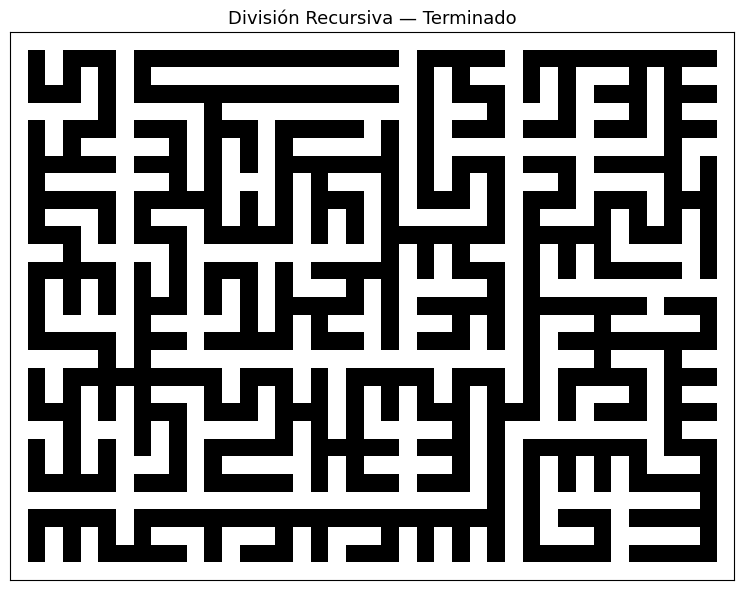

In [6]:
lab_div = generar_division_recursiva(FILAS_P1, COLS_P1, animar=True)

***Comparación Visual: Prim vs División Recursiva***

Se comparan los laberintos generados por ambos algoritmos para ilustrar las diferencias estructurales que impactan en los algoritmos de búsqueda.


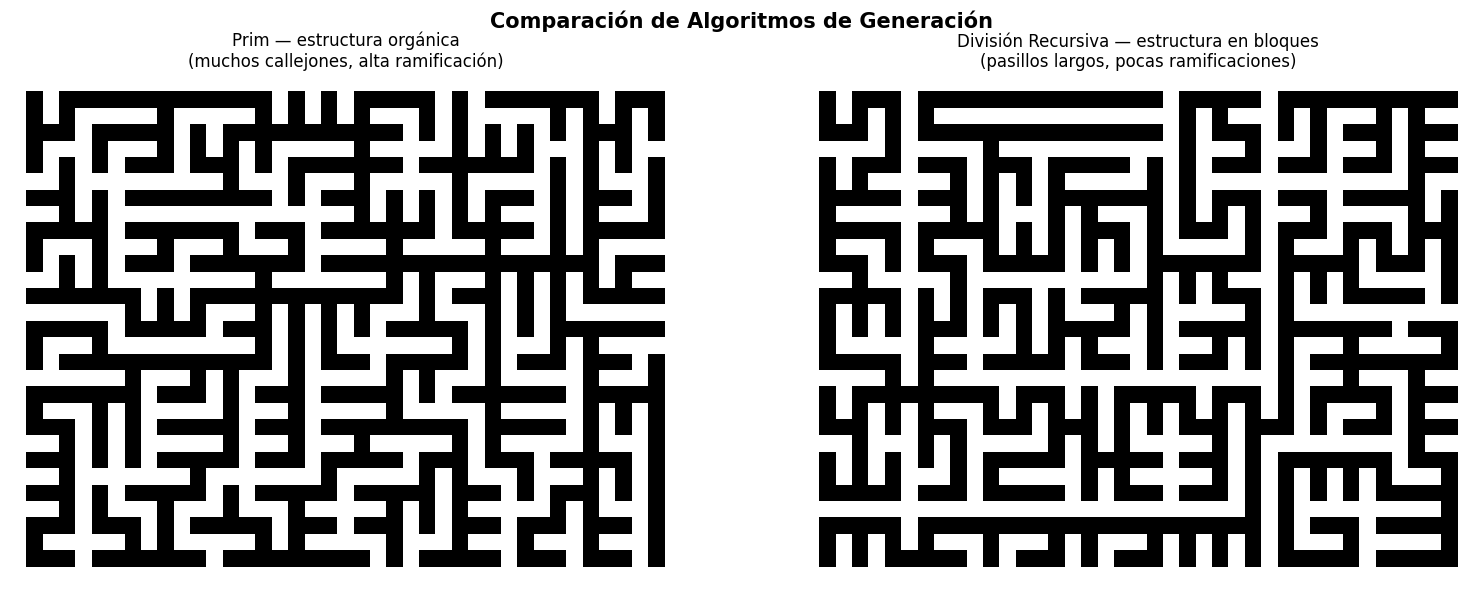

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(lab_prim, cmap='binary')
axes[0].set_title("Prim — estructura orgánica\n(muchos callejones, alta ramificación)", fontsize=12)
axes[0].axis('off')

axes[1].imshow(lab_div, cmap='binary')
axes[1].set_title("División Recursiva — estructura en bloques\n(pasillos largos, pocas ramificaciones)", fontsize=12)
axes[1].axis('off')

plt.suptitle("Comparación de Algoritmos de Generación", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### ***Algoritmos de Búsqueda***

Dado un laberinto de tamaño $60 \times 80$ (generado por los algoritmos de la Sección 1), se implementan los algoritmos de búsqueda para encontrar la ruta más corta entre:
- **Entrada:** celda $A = (1, 1)$
- **Salida:** celda $B = (\text{filas}-2, \text{columnas}-2)$



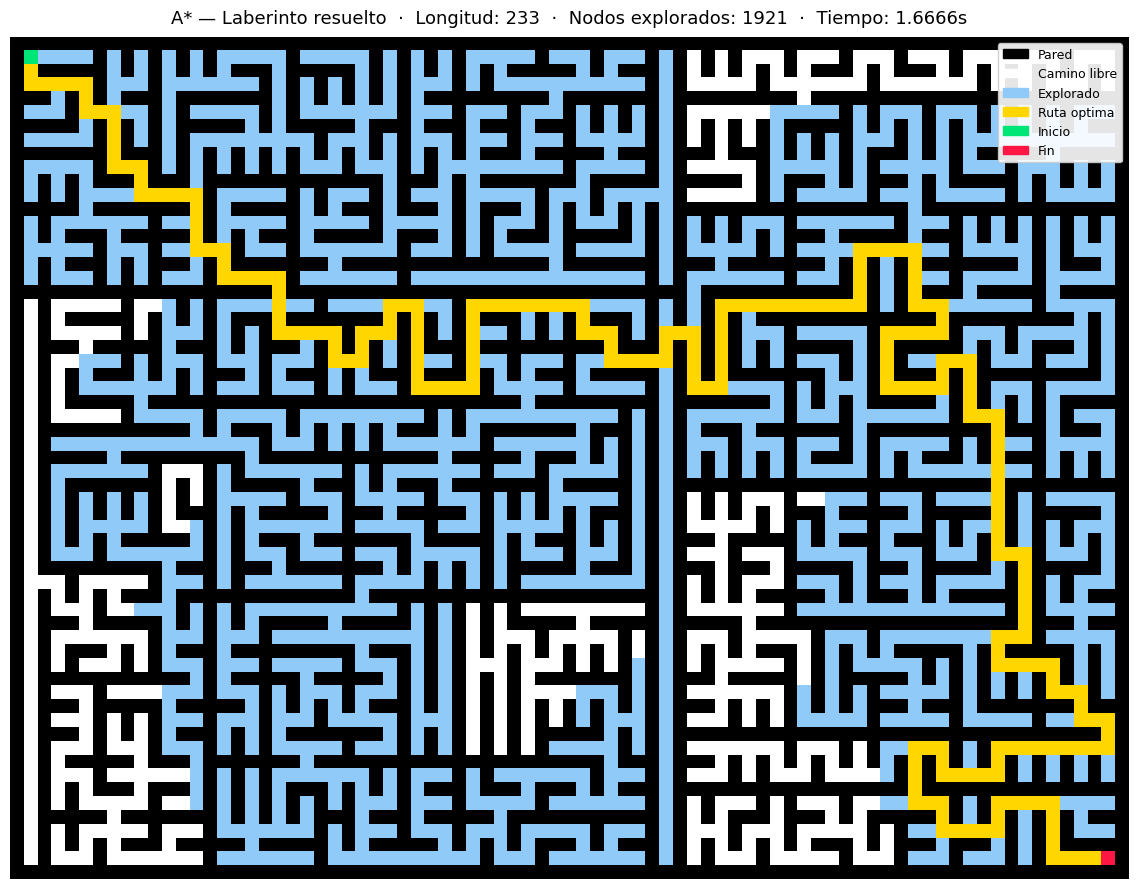


  Laberinto  : Division Recursiva  (60 x 80)
  Longitud   : 233 pasos
  Explorados : 1921 nodos
  Tiempo     : 1.6666s


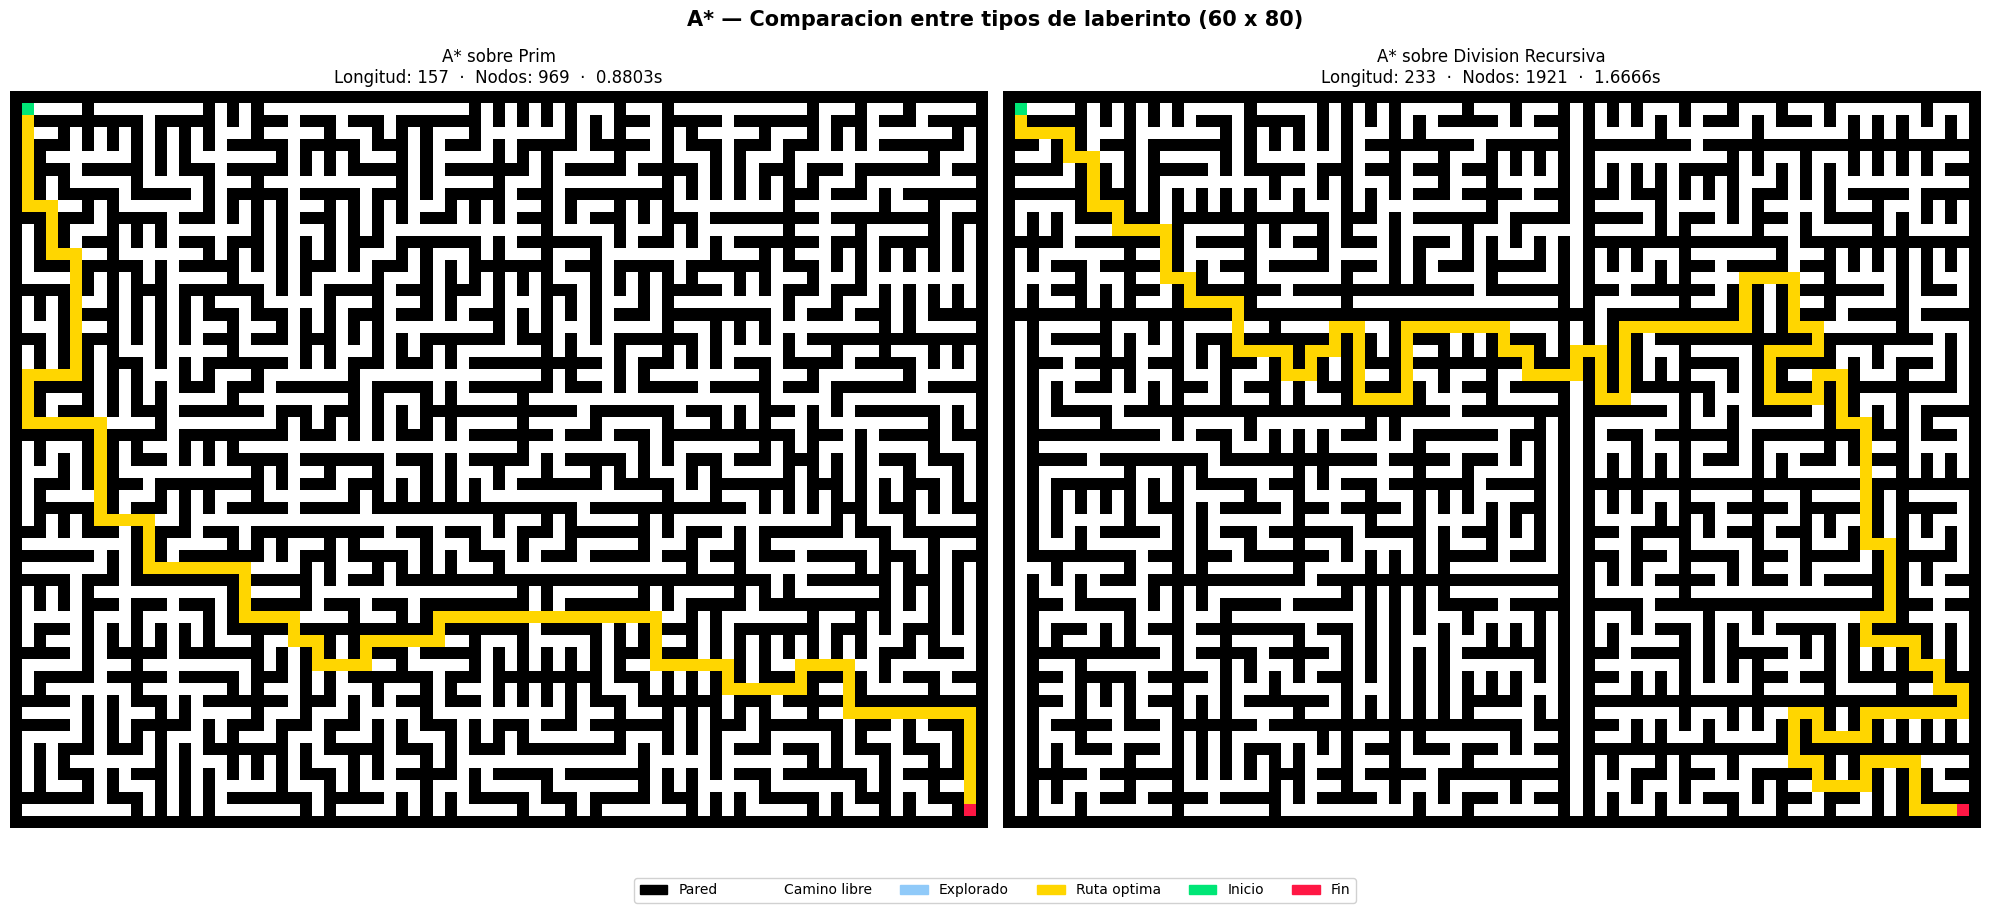

,Laberinto,Longitud camino,Nodos explorados,Tiempo (s)
0,Prim,157,969,0.8803
1,Division Recursiva,233,1921,1.6666


In [ ]:
# Visualización animada de búsqueda 

def dibujar_busqueda(lab_viz, titulo='', pausa=0.01):
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(16, 9))
    ax.imshow(lab_viz, cmap=CMAP_LABERINTO, vmin=0, vmax=5)
    ax.set_title(titulo, fontsize=13, pad=10)
    ax.axis('off')
    leyenda = [
        mpatches.Patch(color='black',   label='Pared'),
        mpatches.Patch(color='white',   label='Camino libre'),
        mpatches.Patch(color='#90CAF9', label='Explorado'),
        mpatches.Patch(color='#FFD600', label='Ruta optima'),
        mpatches.Patch(color='#00E676', label='Inicio'),
        mpatches.Patch(color='#FF1744', label='Fin'),
    ]
    ax.legend(handles=leyenda, loc='upper right', fontsize=9, framealpha=0.9)
    plt.tight_layout()
    plt.show()
    if pausa > 0:
        time.sleep(pausa)


# Algoritmo A* con heurística Manhattan 

def resolver_astar(laberinto, inicio=(1, 1), fin=None, animar=False, pausa=0.003):
    """
    Resuelve el laberinto con A* (heuristica Manhattan).
    Retorna: (camino, nodos_explorados, tiempo_segundos)
    camino es None si no existe solucion.
    """
    filas, cols = laberinto.shape
    if fin is None:
        fin = (filas - 2, cols - 2)

    def h(nodo):
        return abs(nodo[0] - fin[0]) + abs(nodo[1] - fin[1])

    lab_viz = laberinto.copy().astype(float)
    lab_viz[inicio] = COLOR_INICIO
    lab_viz[fin]    = COLOR_FIN

    g_score   = {inicio: 0}
    came_from = {}
    visitados = set()
    contador  = 0
    heap      = [(h(inicio), contador, inicio)]

    nodos_explorados = 0
    t0 = time.time()

    while heap:
        _, _, actual = heapq.heappop(heap)

        if actual in visitados:
            continue
        visitados.add(actual)
        nodos_explorados += 1

        if actual == fin:
            camino = []
            nodo = fin
            while nodo in came_from:
                camino.append(nodo)
                nodo = came_from[nodo]
            camino.append(inicio)
            camino.reverse()

            for c in camino[1:-1]:
                lab_viz[c] = COLOR_RUTA

            tiempo = time.time() - t0
            if animar:
                dibujar_busqueda(
                    lab_viz,
                    f"A* — Laberinto resuelto  ·  Longitud: {len(camino)}  ·  "
                    f"Nodos explorados: {nodos_explorados}  ·  Tiempo: {tiempo:.4f}s",
                    pausa=0
                )
            return camino, nodos_explorados, tiempo

        if actual not in (inicio, fin):
            lab_viz[actual] = COLOR_VISITADO

        if animar and nodos_explorados % 150 == 0:
            dibujar_busqueda(
                lab_viz,
                f"A* explorando...  ·  Nodos explorados: {nodos_explorados}",
                pausa=pausa
            )

        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            vr, vc = actual[0] + dr, actual[1] + dc
            vecino = (vr, vc)
            if (0 <= vr < filas and 0 <= vc < cols
                    and laberinto[vr, vc] == 1
                    and vecino not in visitados):
                g_nuevo = g_score[actual] + 1
                if vecino not in g_score or g_nuevo < g_score[vecino]:
                    g_score[vecino] = g_nuevo
                    came_from[vecino] = actual
                    contador += 1
                    heapq.heappush(heap, (g_nuevo + h(vecino), contador, vecino))

    return None, nodos_explorados, time.time() - t0


# Ejecución: Prim 60×80 

print("Generando laberinto Prim 60x80...")
lab_p2_prim = generar_prim(FILAS_P2, COLS_P2)

print("Resolviendo con A*...")
camino_prim, explorados_prim, tiempo_prim = resolver_astar(
    lab_p2_prim, animar=True, pausa=0.003
)

print(f"\n{'='*52}")
print(f"  Laberinto  : Prim  ({FILAS_P2-1} x {COLS_P2-1})")
print(f"  Longitud   : {len(camino_prim)} pasos")
print(f"  Explorados : {explorados_prim} nodos")
print(f"  Tiempo     : {tiempo_prim:.4f}s")
print(f"{'='*52}")


# Ejecución: División Recursiva 60×80

print("\nGenerando laberinto Division Recursiva 60x80...")
lab_p2_div = generar_division_recursiva(FILAS_P2, COLS_P2)

print("Resolviendo con A*...")
camino_div, explorados_div, tiempo_div = resolver_astar(
    lab_p2_div, animar=True, pausa=0.003
)

print(f"\n{'='*52}")
print(f"  Laberinto  : Division Recursiva  ({FILAS_P2-1} x {COLS_P2-1})")
print(f"  Longitud   : {len(camino_div)} pasos")
print(f"  Explorados : {explorados_div} nodos")
print(f"  Tiempo     : {tiempo_div:.4f}s")
print(f"{'='*52}")


# Comparación visual lado a lado

def lab_resuelto_viz(laberinto, camino):
    lab_viz = laberinto.copy().astype(float)
    inicio  = camino[0]
    fin     = camino[-1]
    for c in camino[1:-1]:
        lab_viz[c] = COLOR_RUTA
    lab_viz[inicio] = COLOR_INICIO
    lab_viz[fin]    = COLOR_FIN
    return lab_viz

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

axes[0].imshow(lab_resuelto_viz(lab_p2_prim, camino_prim),
               cmap=CMAP_LABERINTO, vmin=0, vmax=5)
axes[0].set_title(
    f"A* sobre Prim\nLongitud: {len(camino_prim)}  ·  Nodos: {explorados_prim}  ·  {tiempo_prim:.4f}s",
    fontsize=12)
axes[0].axis('off')

axes[1].imshow(lab_resuelto_viz(lab_p2_div, camino_div),
               cmap=CMAP_LABERINTO, vmin=0, vmax=5)
axes[1].set_title(
    f"A* sobre Division Recursiva\nLongitud: {len(camino_div)}  ·  Nodos: {explorados_div}  ·  {tiempo_div:.4f}s",
    fontsize=12)
axes[1].axis('off')

leyenda = [
    mpatches.Patch(color='black',   label='Pared'),
    mpatches.Patch(color='white',   label='Camino libre'),
    mpatches.Patch(color='#90CAF9', label='Explorado'),
    mpatches.Patch(color='#FFD600', label='Ruta optima'),
    mpatches.Patch(color='#00E676', label='Inicio'),
    mpatches.Patch(color='#FF1744', label='Fin'),
]
fig.legend(handles=leyenda, loc='lower center', ncol=6, fontsize=10,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("A* — Comparacion entre tipos de laberinto (60 x 80)",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


# Tabla resumen

resumen_p2 = pd.DataFrame({
    'Laberinto'         : ['Prim', 'Division Recursiva'],
    'Longitud camino'   : [len(camino_prim), len(camino_div)],
    'Nodos explorados'  : [explorados_prim,  explorados_div],
    'Tiempo (s)'        : [round(tiempo_prim, 4), round(tiempo_div, 4)],
})
display(resumen_p2)


### ***Comparación de Algoritmos***

Se evalúan los algoritmos en múltiples escenarios aleatorios.

In [ ]:
# BFS

def resolver_bfs(laberinto, inicio=(1, 1), fin=None, animar=False, pausa=0.003):
    filas, cols = laberinto.shape
    if fin is None:
        fin = (filas - 2, cols - 2)

    lab_viz = laberinto.copy().astype(float)
    lab_viz[inicio] = COLOR_INICIO
    lab_viz[fin]    = COLOR_FIN

    cola      = deque([inicio])
    visitados = {inicio}
    came_from = {}
    nodos_explorados = 0
    t0 = time.time()

    while cola:
        actual = cola.popleft()
        nodos_explorados += 1

        if actual == fin:
            camino = []
            nodo   = fin
            while nodo in came_from:
                camino.append(nodo)
                nodo = came_from[nodo]
            camino.append(inicio)
            camino.reverse()
            for c in camino[1:-1]:
                lab_viz[c] = COLOR_RUTA
            tiempo = time.time() - t0
            if animar:
                dibujar_busqueda(lab_viz,
                    f"BFS — Resuelto  ·  Longitud: {len(camino)}  ·  "
                    f"Nodos explorados: {nodos_explorados}  ·  Tiempo: {tiempo:.4f}s", 0)
            return camino, nodos_explorados, tiempo

        if actual not in (inicio, fin):
            lab_viz[actual] = COLOR_VISITADO
        if animar and nodos_explorados % 150 == 0:
            dibujar_busqueda(lab_viz, f"BFS explorando...  ·  Nodos: {nodos_explorados}", pausa)

        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            vr, vc = actual[0] + dr, actual[1] + dc
            vecino = (vr, vc)
            if (0 <= vr < filas and 0 <= vc < cols
                    and laberinto[vr, vc] == 1
                    and vecino not in visitados):
                visitados.add(vecino)
                came_from[vecino] = actual
                cola.append(vecino)

    return None, nodos_explorados, time.time() - t0


# DFS 

def resolver_dfs(laberinto, inicio=(1, 1), fin=None, animar=False, pausa=0.003):
    filas, cols = laberinto.shape
    if fin is None:
        fin = (filas - 2, cols - 2)

    lab_viz = laberinto.copy().astype(float)
    lab_viz[inicio] = COLOR_INICIO
    lab_viz[fin]    = COLOR_FIN

    pila      = [inicio]
    visitados = set()
    came_from = {}
    nodos_explorados = 0
    t0 = time.time()

    while pila:
        actual = pila.pop()
        if actual in visitados:
            continue
        visitados.add(actual)
        nodos_explorados += 1

        if actual == fin:
            camino = []
            nodo   = fin
            while nodo in came_from:
                camino.append(nodo)
                nodo = came_from[nodo]
            camino.append(inicio)
            camino.reverse()
            for c in camino[1:-1]:
                lab_viz[c] = COLOR_RUTA
            tiempo = time.time() - t0
            if animar:
                dibujar_busqueda(lab_viz,
                    f"DFS — Resuelto  ·  Longitud: {len(camino)}  ·  "
                    f"Nodos explorados: {nodos_explorados}  ·  Tiempo: {tiempo:.4f}s", 0)
            return camino, nodos_explorados, tiempo

        if actual not in (inicio, fin):
            lab_viz[actual] = COLOR_VISITADO
        if animar and nodos_explorados % 150 == 0:
            dibujar_busqueda(lab_viz, f"DFS explorando...  ·  Nodos: {nodos_explorados}", pausa)

        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            vr, vc = actual[0] + dr, actual[1] + dc
            vecino = (vr, vc)
            if (0 <= vr < filas and 0 <= vc < cols
                    and laberinto[vr, vc] == 1
                    and vecino not in visitados):
                came_from[vecino] = actual
                pila.append(vecino)

    return None, nodos_explorados, time.time() - t0


# Dijkstra (Cost Uniform Search)

def resolver_dijkstra(laberinto, inicio=(1, 1), fin=None, animar=False, pausa=0.003):
    filas, cols = laberinto.shape
    if fin is None:
        fin = (filas - 2, cols - 2)

    lab_viz = laberinto.copy().astype(float)
    lab_viz[inicio] = COLOR_INICIO
    lab_viz[fin]    = COLOR_FIN

    dist      = {inicio: 0}
    came_from = {}
    visitados = set()
    contador  = 0
    heap      = [(0, contador, inicio)]
    nodos_explorados = 0
    t0 = time.time()

    while heap:
        d, _, actual = heapq.heappop(heap)
        if actual in visitados:
            continue
        visitados.add(actual)
        nodos_explorados += 1

        if actual == fin:
            camino = []
            nodo   = fin
            while nodo in came_from:
                camino.append(nodo)
                nodo = came_from[nodo]
            camino.append(inicio)
            camino.reverse()
            for c in camino[1:-1]:
                lab_viz[c] = COLOR_RUTA
            tiempo = time.time() - t0
            if animar:
                dibujar_busqueda(lab_viz,
                    f"Dijkstra — Resuelto  ·  Longitud: {len(camino)}  ·  "
                    f"Nodos explorados: {nodos_explorados}  ·  Tiempo: {tiempo:.4f}s", 0)
            return camino, nodos_explorados, tiempo

        if actual not in (inicio, fin):
            lab_viz[actual] = COLOR_VISITADO
        if animar and nodos_explorados % 150 == 0:
            dibujar_busqueda(lab_viz, f"Dijkstra explorando...  ·  Nodos: {nodos_explorados}", pausa)

        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            vr, vc = actual[0] + dr, actual[1] + dc
            vecino = (vr, vc)
            if (0 <= vr < filas and 0 <= vc < cols
                    and laberinto[vr, vc] == 1
                    and vecino not in visitados):
                nueva_dist = dist[actual] + 1
                if vecino not in dist or nueva_dist < dist[vecino]:
                    dist[vecino]      = nueva_dist
                    came_from[vecino] = actual
                    contador += 1
                    heapq.heappush(heap, (nueva_dist, contador, vecino))

    return None, nodos_explorados, time.time() - t0


# Helper: A y B aleatorios con distancia Manhattan ≥ distancia_min

def puntos_aleatorios(laberinto, distancia_min=10, max_intentos=2000):
    celdas_libres = list(zip(*np.where(laberinto == 1)))
    for _ in range(max_intentos):
        A = random.choice(celdas_libres)
        B = random.choice(celdas_libres)
        if abs(A[0] - B[0]) + abs(A[1] - B[1]) >= distancia_min:
            return A, B
    return celdas_libres[0], celdas_libres[-1]


***Benchmark***

Se generan $K=25$ laberintos de tamaño $45 \times 55$.

Para cada uno:
- Ejecutar BFS, DFS, Dijkstra y A*
- Medir:
  - Nodos explorados
  - Tiempo de ejecución
  - Longitud del camino

In [ ]:
# Benchmark  K=25  grids 45×55

ALGORITMOS = {
    'BFS'     : resolver_bfs,
    'DFS'     : resolver_dfs,
    'Dijkstra': resolver_dijkstra,
    'A*'      : resolver_astar,
}
NOMBRES_ALG  = list(ALGORITMOS.keys())
COLORES_ALG  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

resultados_benchmark = []
mazes_muestra        = {}       # Guarda laberinto+A+B de 3 escenarios para visualización
ESCENARIOS_MUESTRA   = {1, 9, 25}

print("Iniciando benchmark  K=25  (grid 45×55)")
print("=" * 70)

for k in range(K_SIMULACIONES):
    tipo_gen = random.choice(['prim', 'division'])
    if tipo_gen == 'prim':
        lab      = generar_prim(FILAS_P3, COLS_P3)
        tipo_str = 'Prim'
    else:
        lab      = generar_division_recursiva(FILAS_P3, COLS_P3)
        tipo_str = 'Div. Recursiva'

    A, B = puntos_aleatorios(lab, distancia_min=10)

    metricas = {}
    for nombre, fn in ALGORITMOS.items():
        camino, nodos, tiempo = fn(lab, inicio=A, fin=B)
        metricas[nombre] = {
            'nodos'   : nodos,
            'tiempo'  : tiempo,
            'longitud': len(camino) if camino else 0,
        }

    # Ranking: menor nodos explorados = mejor posición
    orden = sorted(metricas, key=lambda a: metricas[a]['nodos'])
    for rango, alg in enumerate(orden, 1):
        metricas[alg]['rank'] = rango

    fila = {'Escenario': k + 1, 'Tipo': tipo_str, 'A': str(A), 'B': str(B)}
    for nombre in NOMBRES_ALG:
        fila[f'{nombre} Nodos'] = metricas[nombre]['nodos']
        fila[f'{nombre} t(s)']  = round(metricas[nombre]['tiempo'], 5)
        fila[f'{nombre} Long.'] = metricas[nombre]['longitud']
        fila[f'{nombre} Rank']  = metricas[nombre]['rank']

    resultados_benchmark.append(fila)

    if k + 1 in ESCENARIOS_MUESTRA:
        mazes_muestra[k + 1] = {
            'lab': lab.copy(), 'A': A, 'B': B,
            'tipo': tipo_str, 'metricas': {n: dict(m) for n, m in metricas.items()}
        }

    winner = orden[0]
    print(f"  [{k+1:2d}/25] {tipo_str:14s}  A={str(A):14s} B={str(B):14s} "
          f"| BFS={metricas['BFS']['nodos']:4d}  DFS={metricas['DFS']['nodos']:4d}  "
          f"Dijk={metricas['Dijkstra']['nodos']:4d}  A*={metricas['A*']['nodos']:4d}"
          f"  → Mejor: {winner}")

df_bench = pd.DataFrame(resultados_benchmark)
print("\nBenchmark completado.")


Iniciando benchmark  K=25  (grid 45×55)
  [ 1/25] Div. Recursiva  A=(np.int64(5), np.int64(32)) B=(np.int64(39), np.int64(14)) | BFS= 863  DFS= 132  Dijk= 863  A*= 338  → Mejor: DFS
  [ 2/25] Prim            A=(np.int64(39), np.int64(13)) B=(np.int64(4), np.int64(29)) | BFS=1042  DFS= 600  Dijk=1042  A*= 768  → Mejor: DFS
  [ 3/25] Prim            A=(np.int64(2), np.int64(25)) B=(np.int64(21), np.int64(43)) | BFS= 242  DFS=1089  Dijk= 242  A*= 137  → Mejor: A*
  [ 4/25] Div. Recursiva  A=(np.int64(8), np.int64(35)) B=(np.int64(17), np.int64(41)) | BFS= 415  DFS= 298  Dijk= 415  A*= 188  → Mejor: A*
  [ 5/25] Prim            A=(np.int64(25), np.int64(37)) B=(np.int64(43), np.int64(35)) | BFS= 497  DFS= 921  Dijk= 497  A*= 231  → Mejor: A*
  [ 6/25] Div. Recursiva  A=(np.int64(25), np.int64(35)) B=(np.int64(16), np.int64(41)) | BFS= 570  DFS=1112  Dijk= 570  A*= 280  → Mejor: A*
  [ 7/25] Div. Recursiva  A=(np.int64(18), np.int64(49)) B=(np.int64(27), np.int64(5)) | BFS=1074  DFS=1010  D

***Tablas***

Se construye una tabla con:
- Algoritmo
- Nodos explorados
- Tiempo
- Longitud del camino

Se calcula ranking por escenario y promedio general.

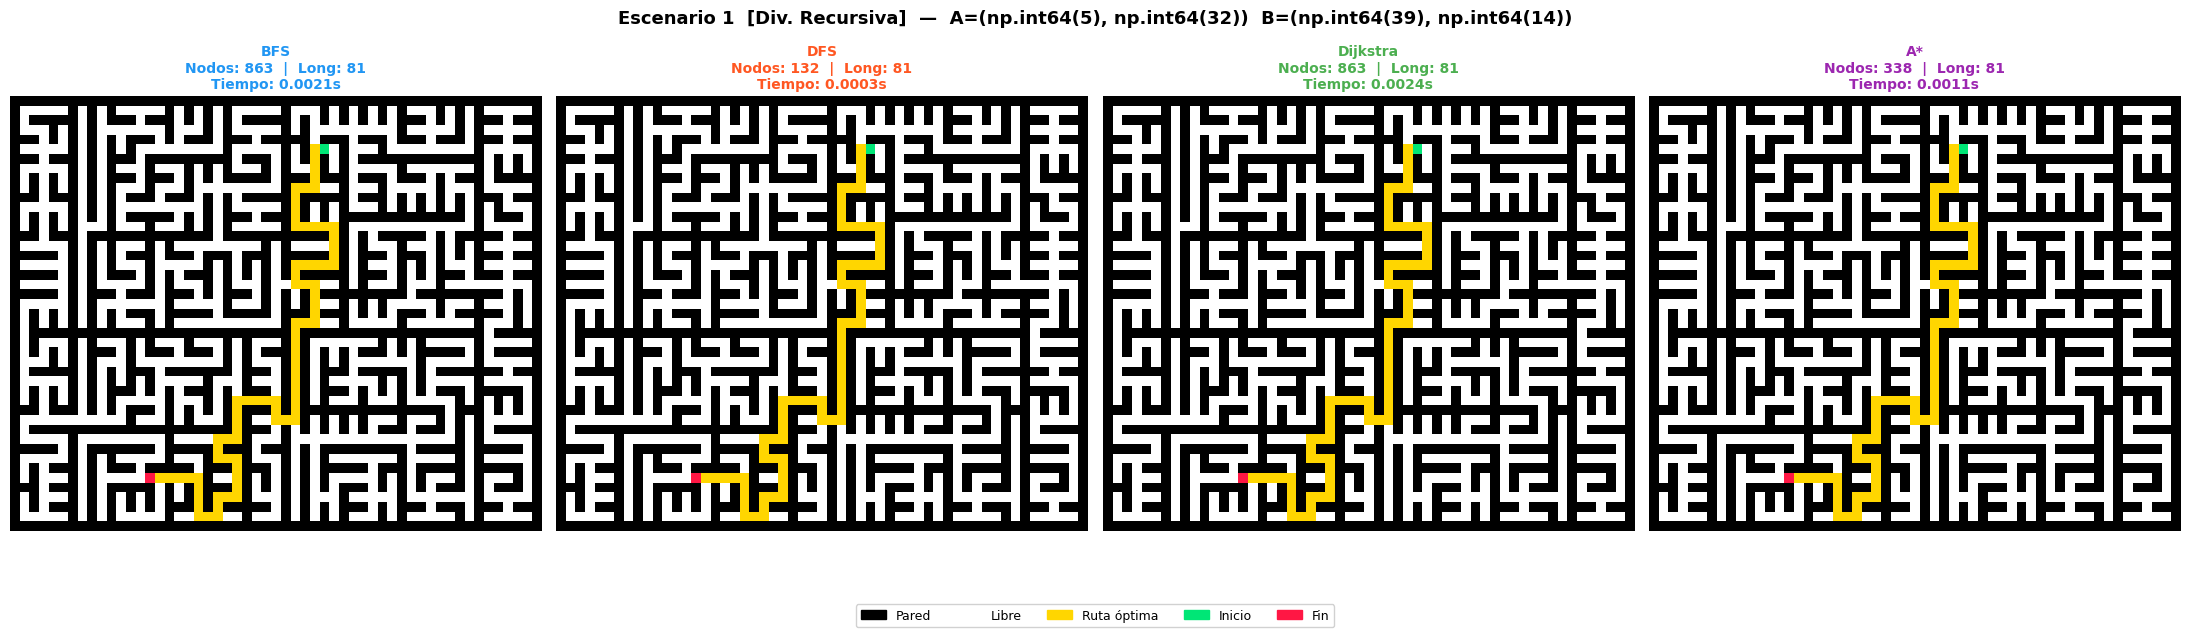


  Escenario 1 — Div. Recursiva  |  A=(np.int64(5), np.int64(32))  B=(np.int64(39), np.int64(14))


,Longitud,Nodos exp.,Tiempo (s),Rank
Algoritmo,,,,
BFS,81,863,0.00281,3
DFS,81,132,0.00033,1
Dijkstra,81,863,0.00232,4
A*,81,338,0.00107,2


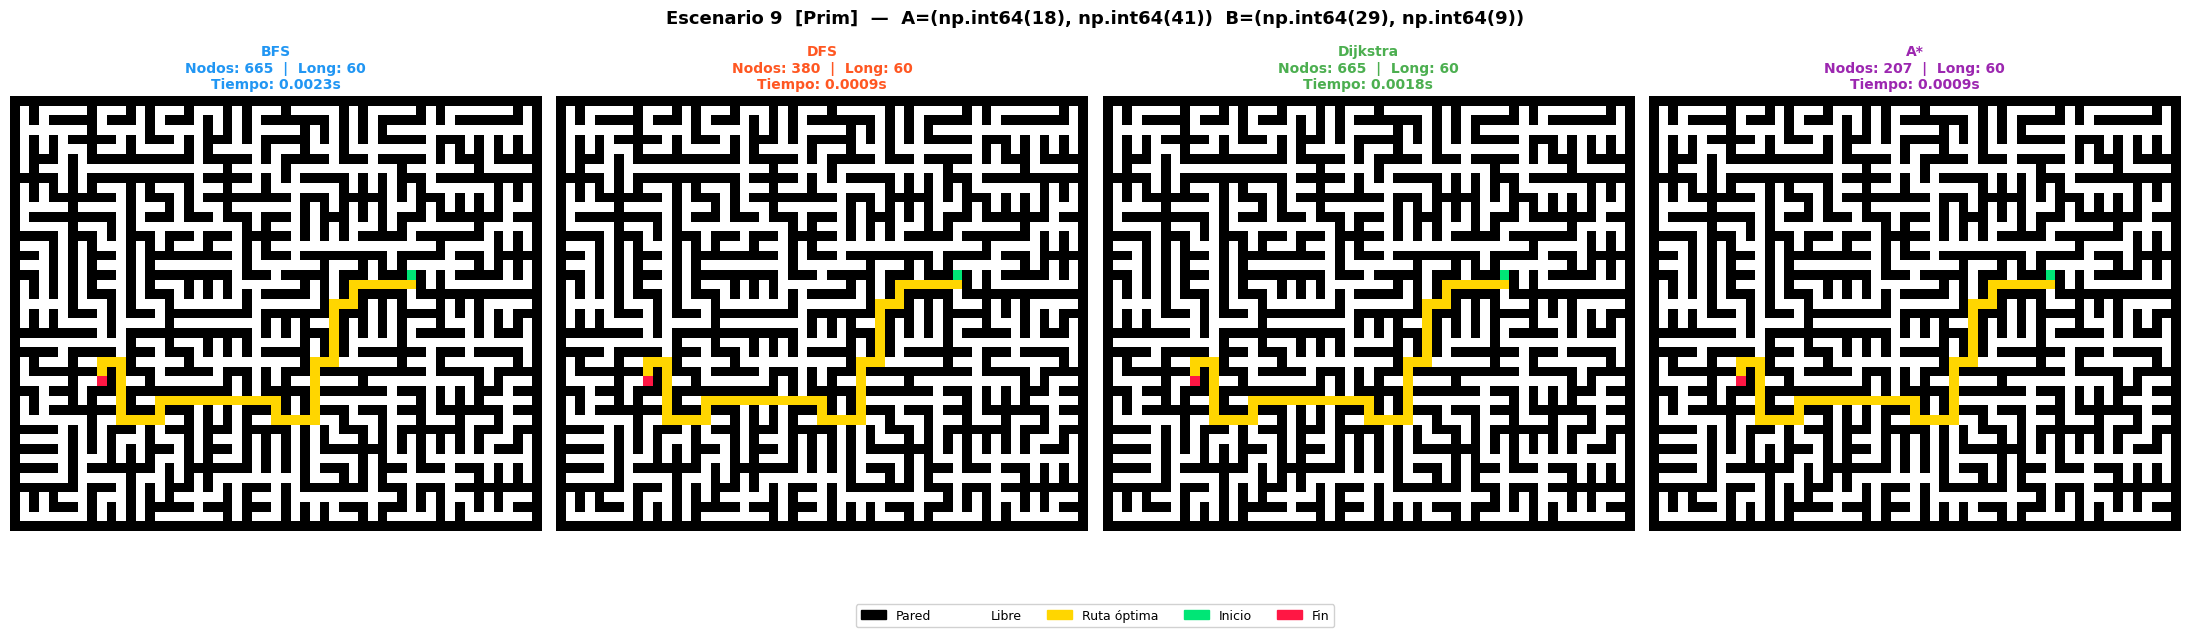


  Escenario 9 — Prim  |  A=(np.int64(18), np.int64(41))  B=(np.int64(29), np.int64(9))


,Longitud,Nodos exp.,Tiempo (s),Rank
Algoritmo,,,,
BFS,60,665,0.00163,3
DFS,60,380,0.00094,2
Dijkstra,60,665,0.00178,4
A*,60,207,0.00064,1


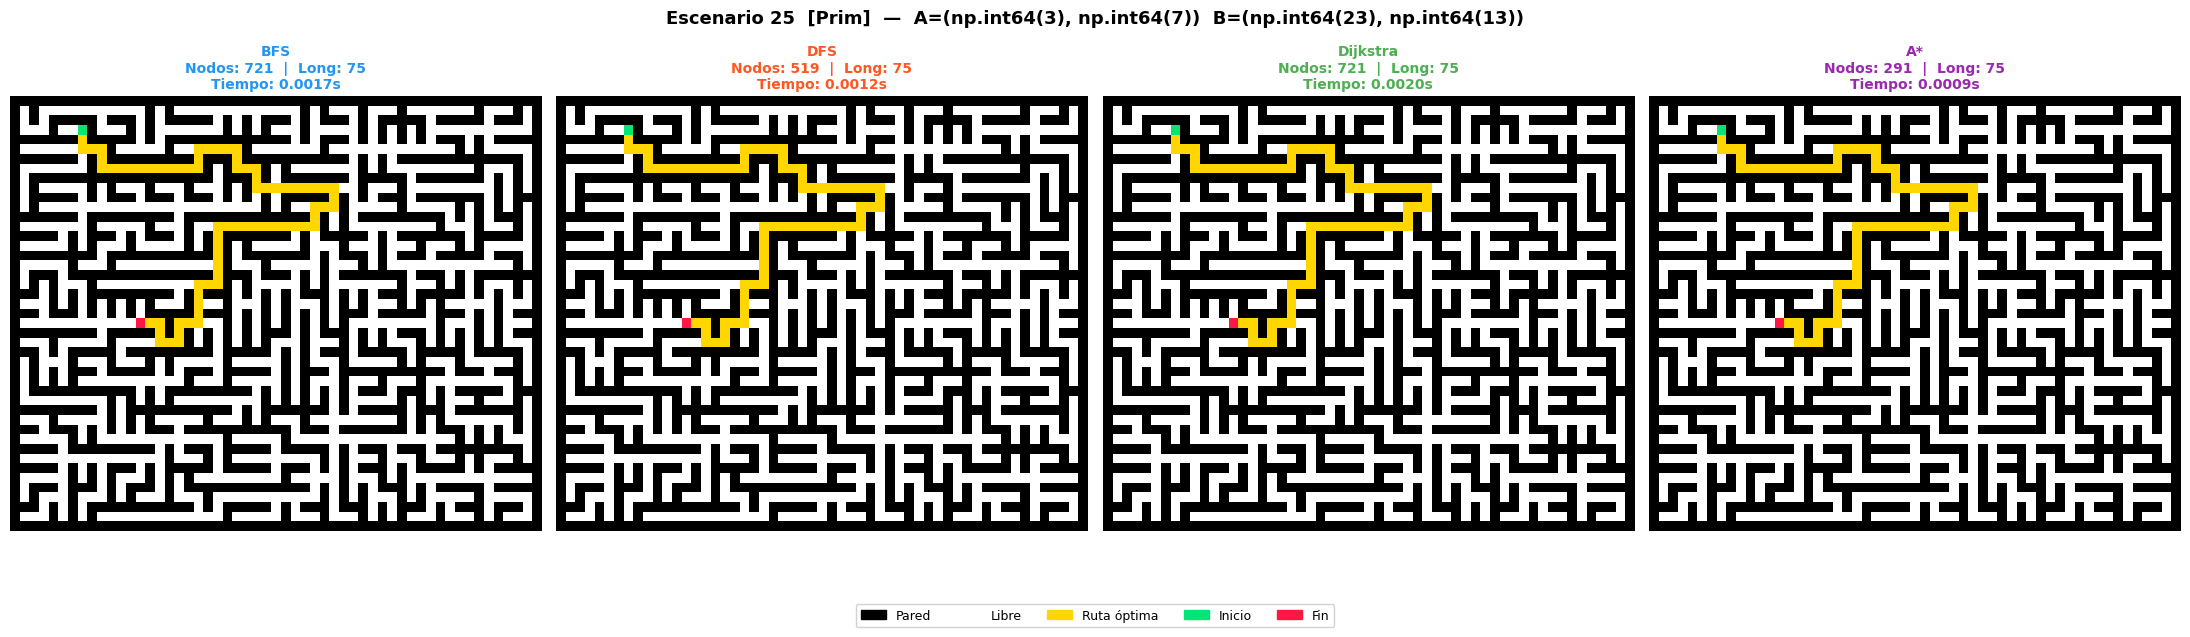


  Escenario 25 — Prim  |  A=(np.int64(3), np.int64(7))  B=(np.int64(23), np.int64(13))


,Longitud,Nodos exp.,Tiempo (s),Rank
Algoritmo,,,,
BFS,75,721,0.00159,3
DFS,75,519,0.00116,2
Dijkstra,75,721,0.00196,4
A*,75,291,0.00091,1




=== RESULTADOS COMPLETOS  (K=25 escenarios) ===



,Escenario,Tipo,BFS Nodos,DFS Nodos,Dijkstra Nodos,A* Nodos,BFS Long.,DFS Long.,Dijkstra Long.,A* Long.,BFS Rank,DFS Rank,Dijkstra Rank,A* Rank
0,1,Div. Recursiva,863,132,863,338,81,81,81,81,3,1,4,2
1,2,Prim,1042,600,1042,768,112,112,112,112,3,1,4,2
2,3,Prim,242,1089,242,137,48,48,48,48,2,4,3,1
3,4,Div. Recursiva,415,298,415,188,40,40,40,40,3,2,4,1
4,5,Prim,497,921,497,231,45,45,45,45,2,4,3,1
5,6,Div. Recursiva,570,1112,570,280,58,58,58,58,2,4,3,1
6,7,Div. Recursiva,1074,1010,1074,885,142,142,142,142,3,2,4,1
7,8,Prim,280,119,280,101,33,33,33,33,3,2,4,1
8,9,Prim,665,380,665,207,60,60,60,60,3,2,4,1
9,10,Div. Recursiva,795,756,795,581,132,132,132,132,3,2,4,1



=== RANKING PROMEDIO GLOBAL (K=25 escenarios) ===



,Algoritmo,Rank promedio,Nodos promedio,Tiempo prom. (s),Longitud prom.,Veces #1,Veces último
Posición,,,,,,,
1,A*,1.2,301.9,0.00106,71.3,20,0
2,BFS,2.6,574.9,0.00149,71.3,0,0
3,DFS,2.6,558.0,0.00143,71.3,5,10
4,Dijkstra,3.6,574.9,0.00160,71.3,0,15


In [ ]:
# Visualización de 3 escenarios representativos

leyenda_patches = [
    mpatches.Patch(color='black',   label='Pared'),
    mpatches.Patch(color='white',   label='Libre'),
    mpatches.Patch(color='#FFD600', label='Ruta óptima'),
    mpatches.Patch(color='#00E676', label='Inicio'),
    mpatches.Patch(color='#FF1744', label='Fin'),
]

for esc_num, datos in sorted(mazes_muestra.items()):
    lab  = datos['lab']
    A, B = datos['A'], datos['B']
    tipo = datos['tipo']

    fig, axes = plt.subplots(1, 4, figsize=(22, 6))

    for ax, nombre, color in zip(axes, NOMBRES_ALG, COLORES_ALG):
        camino, nodos, tiempo = ALGORITMOS[nombre](lab, inicio=A, fin=B)
        lab_viz = lab.copy().astype(float)
        if camino:
            for c in camino[1:-1]:
                lab_viz[c] = COLOR_RUTA
        lab_viz[A] = COLOR_INICIO
        lab_viz[B] = COLOR_FIN
        ax.imshow(lab_viz, cmap=CMAP_LABERINTO, vmin=0, vmax=5)
        long_str = str(len(camino)) if camino else 'sin solución'
        ax.set_title(f"{nombre}\nNodos: {nodos}  |  Long: {long_str}\nTiempo: {tiempo:.4f}s",
                     fontsize=10, color=color, fontweight='bold')
        ax.axis('off')

    fig.legend(handles=leyenda_patches, loc='lower center', ncol=5,
               fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.06))
    plt.suptitle(f"Escenario {esc_num}  [{tipo}]  —  A={A}  B={B}",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\n  Escenario {esc_num} — {tipo}  |  A={A}  B={B}")
    filas_tabla = []
    for nombre in NOMBRES_ALG:
        m = datos['metricas'][nombre]
        filas_tabla.append({
            'Algoritmo': nombre,
            'Longitud' : m['longitud'],
            'Nodos exp.': m['nodos'],
            'Tiempo (s)': round(m['tiempo'], 5),
            'Rank'      : m['rank'],
        })
    display(pd.DataFrame(filas_tabla).set_index('Algoritmo'))
    print()


# Tabla completa de los 25 escenarios

print("\n=== RESULTADOS COMPLETOS  (K=25 escenarios) ===\n")

cols_tabla = (['Escenario', 'Tipo'] +
              [f'{alg} Nodos' for alg in NOMBRES_ALG] +
              [f'{alg} Long.' for alg in NOMBRES_ALG] +
              [f'{alg} Rank'  for alg in NOMBRES_ALG])
display(df_bench[cols_tabla])


# Tabla resumen: ranking promedio global

print("\n=== RANKING PROMEDIO GLOBAL (K=25 escenarios) ===\n")

resumen_rows = []
for nombre in NOMBRES_ALG:
    resumen_rows.append({
        'Algoritmo'        : nombre,
        'Rank promedio'    : round(df_bench[f'{nombre} Rank'].mean(), 2),
        'Nodos promedio'   : round(df_bench[f'{nombre} Nodos'].mean(), 1),
        'Tiempo prom. (s)' : round(df_bench[f'{nombre} t(s)'].mean(), 5),
        'Longitud prom.'   : round(df_bench[f'{nombre} Long.'].mean(), 1),
        'Veces #1'         : int((df_bench[f'{nombre} Rank'] == 1).sum()),
        'Veces último'     : int((df_bench[f'{nombre} Rank'] == 4).sum()),
    })

df_resumen = (pd.DataFrame(resumen_rows)
              .sort_values('Rank promedio')
              .reset_index(drop=True))
df_resumen.index += 1
df_resumen.index.name = 'Posición'
display(df_resumen)


***Gráficas***

Se generan visualizaciones con matplotlib:

- Comparación de tiempos
- Comparación de nodos explorados
- Ranking promedio

Objetivo: identificar tendencias de desempeño.

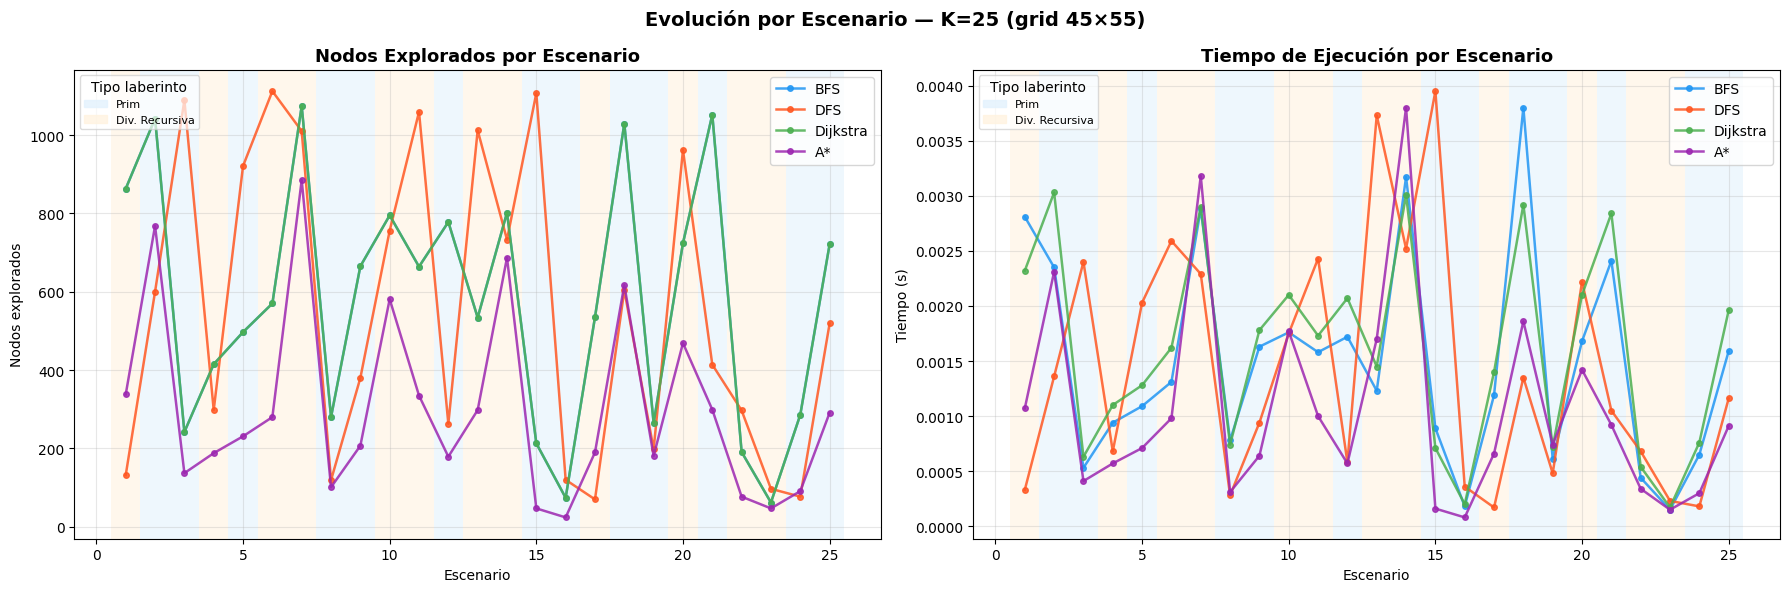

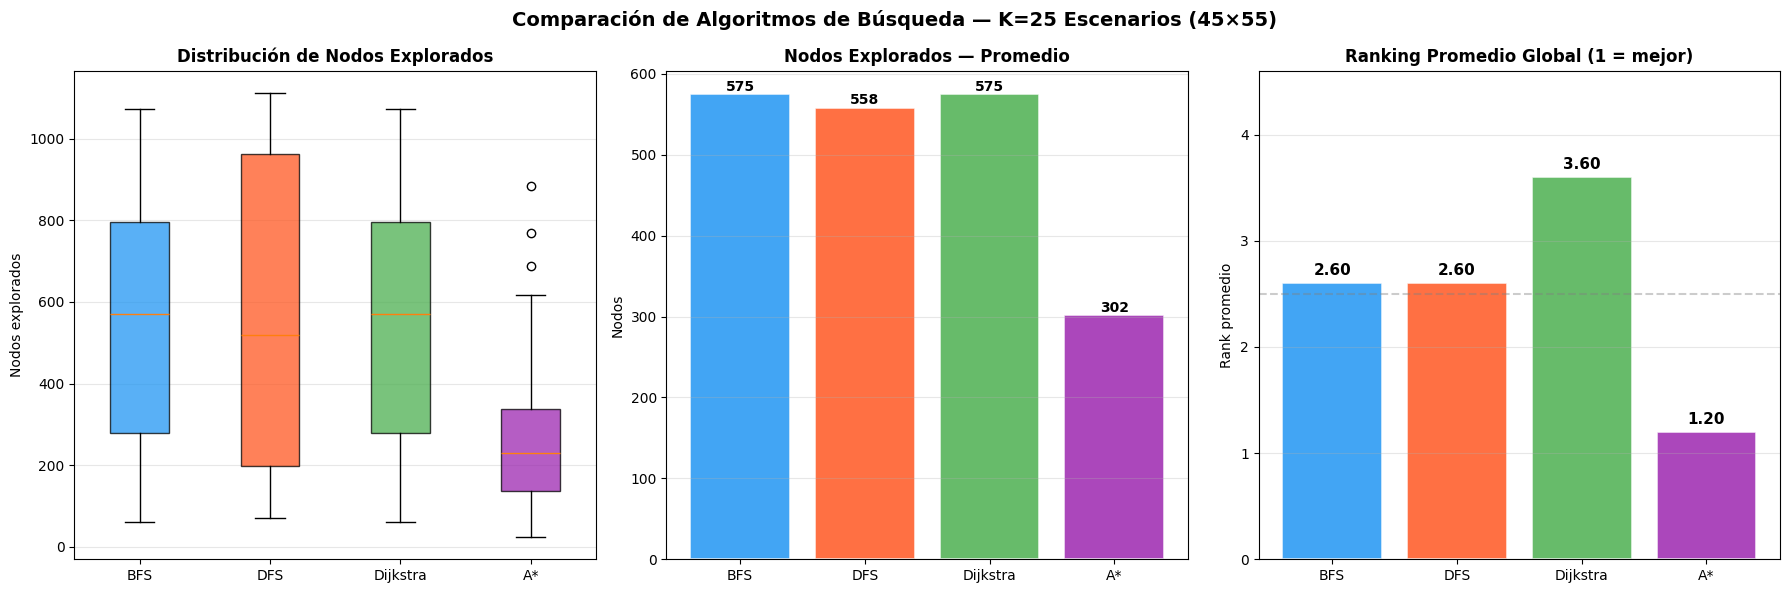

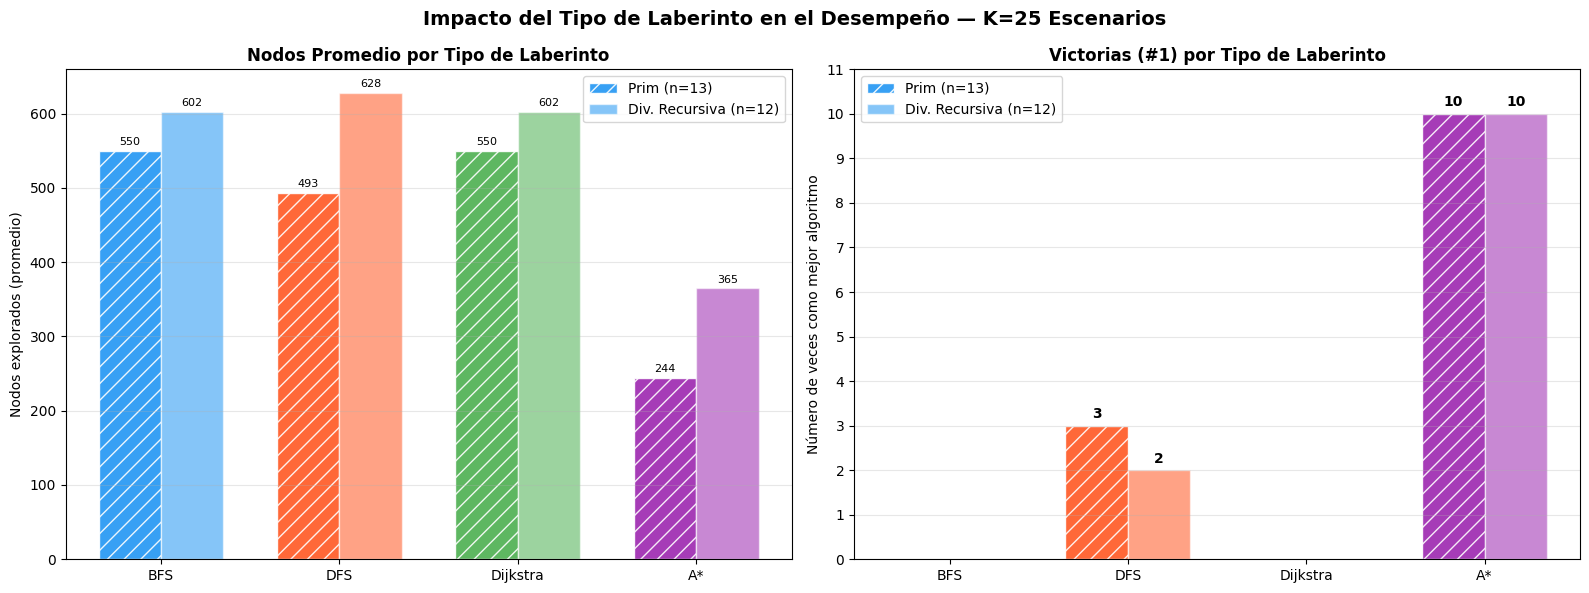

In [ ]:
# Gráfica 1: Nodos y tiempo por escenario

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
escenarios = df_bench['Escenario']

for ax, metrica, ylabel in zip(
    axes,
    ['Nodos', 't(s)'],
    ['Nodos explorados', 'Tiempo (s)']
):
    # Fondo sombreado: Prim=azul claro, Div. Recursiva=naranja claro
    for _, row in df_bench.iterrows():
        color_fondo = '#E3F2FD' if row['Tipo'] == 'Prim' else '#FFF3E0'
        ax.axvspan(row['Escenario'] - 0.5, row['Escenario'] + 0.5,
                   color=color_fondo, alpha=0.6, linewidth=0)

    for nombre, color in zip(NOMBRES_ALG, COLORES_ALG):
        ax.plot(escenarios, df_bench[f'{nombre} {metrica}'],
                label=nombre, color=color, linewidth=1.8,
                marker='o', markersize=4, alpha=0.85)

    titulo = 'Nodos Explorados por Escenario' if metrica == 'Nodos' else 'Tiempo de Ejecución por Escenario'
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_xlabel('Escenario')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    prim_patch = mpatches.Patch(color='#E3F2FD', label='Prim', alpha=0.8)
    div_patch  = mpatches.Patch(color='#FFF3E0', label='Div. Recursiva', alpha=0.8)
    leg2 = ax.legend(handles=[prim_patch, div_patch], loc='upper left',
                     fontsize=8, framealpha=0.7, title='Tipo laberinto')
    ax.add_artist(leg2)
    ax.legend(fontsize=10, loc='upper right')

plt.suptitle('Evolución por Escenario — K=25 (grid 45×55)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# Gráfica 2: Distribución y ranking promedio 

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Boxplot nodos explorados
ax = axes[0]
datos_nodos = [df_bench[f'{alg} Nodos'].values for alg in NOMBRES_ALG]
bp = ax.boxplot(datos_nodos, tick_labels=NOMBRES_ALG, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], COLORES_ALG):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_title('Distribución de Nodos Explorados', fontsize=12, fontweight='bold')
ax.set_ylabel('Nodos explorados')
ax.grid(alpha=0.3, axis='y')

# Barras: nodos promedio
ax = axes[1]
nodos_prom = [df_bench[f'{alg} Nodos'].mean() for alg in NOMBRES_ALG]
bars = ax.bar(NOMBRES_ALG, nodos_prom, color=COLORES_ALG, alpha=0.85, edgecolor='white', linewidth=1.2)
ax.set_title('Nodos Explorados — Promedio', fontsize=12, fontweight='bold')
ax.set_ylabel('Nodos')
for bar, val in zip(bars, nodos_prom):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# Barras: ranking promedio global
ax = axes[2]
ranks_prom = [df_bench[f'{alg} Rank'].mean() for alg in NOMBRES_ALG]
bars = ax.bar(NOMBRES_ALG, ranks_prom, color=COLORES_ALG, alpha=0.85, edgecolor='white', linewidth=1.2)
ax.set_title('Ranking Promedio Global (1 = mejor)', fontsize=12, fontweight='bold')
ax.set_ylabel('Rank promedio')
ax.set_ylim(0, 4.6)
ax.axhline(y=2.5, color='gray', linestyle='--', alpha=0.4)
for bar, rank in zip(bars, ranks_prom):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{rank:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.suptitle('Comparación de Algoritmos de Búsqueda — K=25 Escenarios (45×55)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# Gráfica 3: Nodos explorados desglosado por tipo de laberinto

df_prim = df_bench[df_bench['Tipo'] == 'Prim']
df_div  = df_bench[df_bench['Tipo'] == 'Div. Recursiva']

x      = np.arange(len(NOMBRES_ALG))
width  = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo: nodos promedio por tipo
ax = axes[0]
bars_p = ax.bar(x - width/2,
                [df_prim[f'{a} Nodos'].mean() for a in NOMBRES_ALG],
                width, label=f'Prim (n={len(df_prim)})',
                color=COLORES_ALG, alpha=0.9, edgecolor='white', hatch='//')
bars_d = ax.bar(x + width/2,
                [df_div[f'{a} Nodos'].mean() for a in NOMBRES_ALG],
                width, label=f'Div. Recursiva (n={len(df_div)})',
                color=COLORES_ALG, alpha=0.55, edgecolor='white')

for bar in list(bars_p) + list(bars_d):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(NOMBRES_ALG)
ax.set_title('Nodos Promedio por Tipo de Laberinto', fontsize=12, fontweight='bold')
ax.set_ylabel('Nodos explorados (promedio)')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')

# Panel derecho: victorias (#1) por tipo de laberinto
ax = axes[1]
wins_prim = [int((df_prim[f'{a} Rank'] == 1).sum()) for a in NOMBRES_ALG]
wins_div  = [int((df_div[f'{a} Rank']  == 1).sum()) for a in NOMBRES_ALG]

bars_wp = ax.bar(x - width/2, wins_prim, width,
                 label=f'Prim (n={len(df_prim)})',
                 color=COLORES_ALG, alpha=0.9, edgecolor='white', hatch='//')
bars_wd = ax.bar(x + width/2, wins_div, width,
                 label=f'Div. Recursiva (n={len(df_div)})',
                 color=COLORES_ALG, alpha=0.55, edgecolor='white')

for bar in list(bars_wp) + list(bars_wd):
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(int(bar.get_height())), ha='center', va='bottom',
                fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(NOMBRES_ALG)
ax.set_title('Victorias (#1) por Tipo de Laberinto', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de veces como mejor algoritmo')
ax.set_yticks(range(0, max(wins_prim + wins_div) + 2))
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')

plt.suptitle('Impacto del Tipo de Laberinto en el Desempeño — K=25 Escenarios',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()